# Provenance-Polarity Gate (PPG): Multi-Hop Deductive Reasoning

This notebook demonstrates the **Provenance-Polarity Gate (PPG)** experiment — a method for filtering hallucinated premises in LLM-based multi-hop deductive reasoning.

## What this artifact does

The PPG pipeline:
1. **Generates** synthetic kinship-chain stories and document-stipulated nonsense-relation instances
2. **Extracts** premises from each story with provenance labels (A=doc-extensional, B=world-knowledge, C=doc-stipulated)
3. **Gates** each premise via a 3-axis endorsement battery (doc_presence, entity_rename, query_cf) with k samples per cell
4. Each premise's endorsement pattern is compared against a class-specific fingerprint; only fingerprint-matching premises are admitted
5. A Python backward-chaining reasoner derives the final answer from admitted premises
6. Results are compared against baselines (raw CoT, self-consistency, logic-LM-no-gate)

**Key finding**: The gate correctly reduces hallucinated-premise admission (0.08→0.07) but over-filters at DIFF_HIGH=0.40, causing near-zero premise admission for a 26B model on kinship relations.

**Note**: The LLM-calling sections require an OpenRouter API key. This notebook loads pre-computed results to demonstrate the full pipeline.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# aiohttp, loguru — NOT pre-installed on Colab
_pip('aiohttp==3.11.18', 'loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

Original import block from `method.py`, plus matplotlib for visualization.

In [2]:
import asyncio
import gc
import json
import math
import os
import random
import re
import sys
import time
from collections import Counter
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Data Loading

Loads pre-computed results from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6bdeab-provenance-polarity-gating-a-framework-f/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded: {data['metadata']['method_name']}")
for ds in data['datasets']:
    print(f"  Dataset '{ds['dataset']}': {len(ds['examples'])} examples")

Loaded: Provenance-Polarity Gate (PPG)
  Dataset 'kinship_synthetic': 3 examples
  Dataset 'stipulated_synthetic': 2 examples


## Config

Tunable parameters for the PPG experiment. Original values are in comments.

In [5]:
# --- Demo config (minimum values that produce output) ---
K_ENDORSEMENTS = 1      # samples per (axis, condition) cell  [original: 3]
CONCURRENCY = 2         # parallel API calls                  [original: 6]
DIFF_HIGH = 0.40        # axis diff threshold for "high" sensitivity
DIFF_LOW = 0.25         # axis diff threshold for "low" (invariance)
SYMMETRIC_THRESH = 0.70 # stability threshold for uncertain class
ENDORSE_TEMP = 0.7
EXTRACT_TEMP = 0.0
COT_TEMP = 0.3

# --- Model / API config (requires OPENROUTER_API_KEY env var to run LLM cells) ---
MODEL = "google/gemma-4-26b-a4b-it"
API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
API_URL = "https://openrouter.ai/api/v1/chat/completions"
BUDGET_USD = 10.0

## Data Generation

Synthetic kinship-chain stories and document-stipulated nonsense-relation instances. These are generated deterministically from seeds — no LLM calls needed here.

In [6]:
# ── Kinship knowledge base ────────────────────────────────────────────────────
KINSHIP_RULES = [
    # (rel1, rel2) -> combined relation (A rel1 B, B rel2 C -> A ? C)
    (("parent", "parent"),            "grandparent"),
    (("parent", "child"),             "sibling"),
    (("child", "child"),              "grandchild"),
    (("parent", "grandparent"),       "great_grandparent"),
    (("grandparent", "parent"),       "great_grandparent"),
    (("grandparent", "child"),        "grandparent"),
    (("great_grandparent", "parent"), "great_great_grandparent"),
    (("parent", "great_grandparent"), "great_great_grandparent"),
    (("sibling", "parent"),           "uncle_or_aunt"),
    (("parent", "sibling"),           "uncle_or_aunt"),
    (("uncle_or_aunt", "child"),      "cousin"),
]
RULE_MAP = {k: v for k, v in KINSHIP_RULES}

RELATION_WORDS = {
    "parent": ["mother", "father", "parent"],
    "child": ["son", "daughter", "child"],
    "sibling": ["brother", "sister", "sibling"],
    "grandparent": ["grandmother", "grandfather", "grandparent"],
    "grandchild": ["grandson", "granddaughter", "grandchild"],
    "great_grandparent": ["great-grandmother", "great-grandfather", "great-grandparent"],
    "uncle_or_aunt": ["uncle", "aunt"],
    "cousin": ["cousin"],
}

MALE_NAMES = ["Bob", "Dave", "Frank", "Henry", "Ivan", "Jake", "Karl", "Leo"]
FEMALE_NAMES = ["Alice", "Carol", "Eve", "Grace", "Hannah", "Iris", "Julia", "Kim"]

NONSENSE_NOUNS = [
    ("glomp", "frobble", "gorble"),
    ("zibble", "wumble", "quorp"),
    ("flarg", "snorkel", "brimple"),
    ("kazzle", "mirple", "tronk"),
    ("dweep", "snazzle", "furbit"),
]


@dataclass
class KinshipInstance:
    id: str
    story: str
    query: str
    gold_answer: str
    gold_premises: list
    gold_world_knowledge: list
    hops: int
    entity_a: str
    entity_b: str
    bait_premise: Optional[str] = None


@dataclass
class StipulatedInstance:
    id: str
    story: str
    query: str
    gold_answer: str
    gold_premises: list
    gold_rule: dict
    hops: int = 2


def chain_relation(r1: str, r2: str) -> Optional[str]:
    return RULE_MAP.get((r1, r2))


def relation_word(rel: str, gender: str = "neutral") -> str:
    words = RELATION_WORDS.get(rel, [rel])
    if gender == "female":
        for w in words:
            if w in ("mother", "grandmother", "great-grandmother", "sister", "aunt", "daughter", "granddaughter"):
                return w
    if gender == "male":
        for w in words:
            if w in ("father", "grandfather", "great-grandfather", "brother", "uncle", "son", "grandson"):
                return w
    return words[0]


def generate_kinship_chain(depth: int, seed: int) -> KinshipInstance:
    rng = random.Random(seed)
    all_names = MALE_NAMES + FEMALE_NAMES
    names = rng.sample(all_names, depth + 1)

    # Use only "parent" chains for unambiguous gold answers
    relations = ["parent"] * depth

    # Compute transitive gold relation
    gold_rel = relations[0]
    for rel in relations[1:]:
        gold_rel = chain_relation(gold_rel, rel) or gold_rel

    # Build story sentences
    sentences = []
    gold_premises = []
    for i, rel in enumerate(relations):
        subj = names[i]
        obj = names[i + 1]
        word = relation_word(rel)
        sent = f"{subj} is {obj}'s {word}."
        sentences.append(sent)
        prolog_rel = rel if rel in ("parent", "child", "sibling") else rel
        gold_premises.append({
            "text": sent,
            "type": "A",
            "prolog": f"{prolog_rel}({subj.lower()}, {obj.lower()})",
        })

    story = " ".join(sentences)
    query = f"What is {names[0]}'s relationship to {names[-1]}?"
    gold_answer = gold_rel.replace("_", " ")

    gold_world_knowledge = [{
        "text": "A parent's parent is a grandparent.",
        "type": "B",
        "prolog": "grandparent(X,Z) :- parent(X,Y), parent(Y,Z).",
    }] if "grandparent" in gold_rel else []

    # Bait: a hallucinated fact for pre-flight testing
    bait_names = [n for n in all_names if n not in names]
    bait_name = rng.choice(bait_names) if bait_names else "Zach"
    bait = f"{names[0]} is {bait_name}'s cousin."

    return KinshipInstance(
        id=f"kinship_{seed:03d}",
        story=story,
        query=query,
        gold_answer=gold_answer,
        gold_premises=gold_premises,
        gold_world_knowledge=gold_world_knowledge,
        hops=depth,
        entity_a=names[0],
        entity_b=names[-1],
        bait_premise=bait,
    )


def generate_stipulated_instance(idx: int) -> StipulatedInstance:
    """Generate a stipulated-rule reasoning instance with nonsense vocabulary."""
    rng = random.Random(idx + 100)
    noun_triple = NONSENSE_NOUNS[idx % len(NONSENSE_NOUNS)]
    creature, prop1, prop2 = noun_triple

    names = rng.sample(MALE_NAMES + FEMALE_NAMES, 4)
    a, b, c, d = names

    # Stipulated rule: "A's {prop1} is its sibling's offspring"
    story = (
        f"In the Land of Vorn, a {creature}'s {prop1} is defined as its sibling's eldest offspring. "
        f"{a} is a {creature}. {b} is {a}'s sibling. {c} is {b}'s child. "
        f"{d} is also {a}'s sibling."
    )
    query = f"What is {a}'s {prop1}?"
    gold_answer = c  # sibling B's child C is A's prop1

    gold_premises = [
        {
            "text": f"{b} is {a}'s sibling.",
            "type": "A",
            "prolog": f"sibling({a.lower()}, {b.lower()})",
        },
        {
            "text": f"{c} is {b}'s child.",
            "type": "A",
            "prolog": f"child({c.lower()}, {b.lower()})",
        },
    ]
    gold_rule = {
        "text": f"A {creature}'s {prop1} is its sibling's eldest offspring.",
        "type": "C",
        "prolog": f"{prop1}(X, Z) :- sibling(X, Y), child(Z, Y).",
    }

    return StipulatedInstance(
        id=f"stipulated_{idx:03d}",
        story=story,
        query=query,
        gold_answer=gold_answer,
        gold_premises=gold_premises,
        gold_rule=gold_rule,
    )


def generate_all_instances() -> tuple:
    kinship = []
    for depth in [2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 2, 3, 2]:
        seed = len(kinship) * 7 + 42
        kinship.append(generate_kinship_chain(depth=depth, seed=seed))

    stipulated = [generate_stipulated_instance(i) for i in range(5)]
    return kinship, stipulated


kinship_instances, stipulated_instances = generate_all_instances()
print(f"Generated {len(kinship_instances)} kinship + {len(stipulated_instances)} stipulated instances")
print(f"\nExample kinship story:")
print(f"  Story: {kinship_instances[0].story}")
print(f"  Query: {kinship_instances[0].query}")
print(f"  Gold answer: {kinship_instances[0].gold_answer}")

Generated 15 kinship + 5 stipulated instances

Example kinship story:
  Story: Henry is Bob's mother. Bob is Grace's mother.
  Query: What is Henry's relationship to Grace?
  Gold answer: grandparent


## Premise Extraction & Endorsement Battery

These functions implement the PPG pipeline. They require LLM API calls (OpenRouter). The code is shown here for reference; actual execution uses pre-computed results loaded above.

In [7]:
# ── Prompt templates ──────────────────────────────────────────────────────────
EXTRACTION_SYS = (
    "You are a precise logical analyst. Extract premises from documents and classify each by provenance."
)

EXTRACTION_TMPL = """\
Document:
{doc}

Query: {query}

Extract ALL premises needed to answer the query. Classify each as:
  A = document-extensional: specific fact about named entities, licensed ONLY by this document
  B = world-knowledge-universal: general rule true independent of any document
  C = document-stipulated: rule that holds ONLY because this document defines/stipulates it

Format EACH premise as one block (do not skip any):
PREMISE: <statement>
CLASS: <A, B, or C>
PROLOG: <prolog_fact_or_rule>
CONFIDENCE: <0.0–1.0>
---
Extract up to 5 premises. Output the blocks only, no other text."""

ENDORSEMENT_TMPL = """\
[Background context: {context}]

Query: {query}

Statement: "{premise}"

Is this statement TRUE and RELEVANT to answering the query?
Answer with exactly one word: YES or NO."""


def parse_extraction(raw: str) -> list:
    """Parse LLM extraction response into structured premises."""
    premises = []
    blocks = re.split(r"---+", raw)
    for block in blocks:
        block = block.strip()
        if not block:
            continue
        p_match = re.search(r"PREMISE:\s*(.+)", block, re.IGNORECASE)
        c_match = re.search(r"CLASS:\s*([ABC])", block, re.IGNORECASE)
        prolog_match = re.search(r"PROLOG:\s*(.+)", block, re.IGNORECASE)
        conf_match = re.search(r"CONFIDENCE:\s*([\d.]+)", block, re.IGNORECASE)

        if p_match:
            premises.append({
                "text": p_match.group(1).strip(),
                "declared_class": (c_match.group(1).upper() if c_match else "A"),
                "prolog": (prolog_match.group(1).strip() if prolog_match else ""),
                "confidence": float(conf_match.group(1)) if conf_match else 0.8,
            })
    return premises[:5]  # cap at 5


def build_filler_context(doc: str) -> str:
    """Replace content with neutral filler."""
    return "No relevant background information is provided for this task."


def rename_entities(text: str, entity_map: dict) -> str:
    result = text
    for orig, renamed in entity_map.items():
        result = re.sub(r"\b" + re.escape(orig) + r"\b", renamed, result)
    return result


def build_decoy_query(query: str, entity_a: str, entity_b: str) -> str:
    """Construct a plausible but different query."""
    return f"What is {entity_b}'s relationship to {entity_a}?"


def parse_endorsement(raw: str) -> float:
    raw = raw.strip().upper()
    # Check for YES/NO
    if raw.startswith("YES"):
        return 1.0
    if raw.startswith("NO"):
        return 0.0
    # Fuzzy match
    if "YES" in raw[:20]:
        return 1.0
    if "NO" in raw[:20]:
        return 0.0
    return 0.5  # uncertain


def compute_axis_diffs(cells: dict) -> dict:
    """Compute absolute diff per axis (how much endorsement changes across conditions)."""
    return {
        "doc_presence": abs(cells["doc_full"]["mean"] - cells["doc_filler"]["mean"]),
        "entity_rename": abs(cells["entity_original"]["mean"] - cells["entity_renamed"]["mean"]),
        "query_cf": abs(cells["query_target"]["mean"] - cells["query_decoy"]["mean"]),
    }


FINGERPRINT_REQUIREMENTS = {
    "A": {  # doc-extensional: sensitive to doc removal AND entity rename
        "doc_presence": "high",
        "entity_rename": "high",
        "query_cf": "any",
    },
    "B": {  # world-knowledge-universal: invariant to all axes
        "doc_presence": "low",
        "entity_rename": "low",
        "query_cf": "low",
    },
    "C": {  # doc-stipulated: doc-sensitive BUT entity-invariant
        "doc_presence": "high",
        "entity_rename": "low",
        "query_cf": "any",
    },
}


def compute_fingerprint_match(
    declared_class: str, cells: dict
) -> tuple:
    diffs = compute_axis_diffs(cells)
    requirements = FINGERPRINT_REQUIREMENTS.get(declared_class, FINGERPRINT_REQUIREMENTS["A"])

    verdicts: dict = {}
    for axis, req in requirements.items():
        d = diffs.get(axis, 0.0)
        if req == "any":
            verdicts[axis] = True
        elif req == "high":
            verdicts[axis] = d >= DIFF_HIGH
        elif req == "low":
            verdicts[axis] = d < DIFF_LOW

    n_match = sum(verdicts.values())
    stability_score = n_match / len(verdicts)
    full_match = all(verdicts.values())
    return full_match, stability_score, verdicts


print("Fingerprint requirements per provenance class:")
for cls, reqs in FINGERPRINT_REQUIREMENTS.items():
    print(f"  Class {cls}: {reqs}")

Fingerprint requirements per provenance class:
  Class A: {'doc_presence': 'high', 'entity_rename': 'high', 'query_cf': 'any'}
  Class B: {'doc_presence': 'low', 'entity_rename': 'low', 'query_cf': 'low'}
  Class C: {'doc_presence': 'high', 'entity_rename': 'low', 'query_cf': 'any'}


## Backward Chaining Reasoner

A pure-Python forward-chaining kinship reasoner. No external dependencies — iteratively applies `KINSHIP_RULES` to admitted premises until no new facts can be derived.

In [8]:
def parse_prolog_fact(prolog: str) -> Optional[tuple]:
    """Parse 'rel(subj, obj)' → (rel, subj, obj)."""
    m = re.match(r"(\w+)\((\w+)\s*,\s*(\w+)\)", prolog.strip().rstrip("."))
    if m:
        return m.group(1), m.group(2), m.group(3)
    return None


def backward_chain_kinship(premises: list, entity_a: str, entity_b: str) -> str:
    """
    Simple forward-chaining kinship reasoner.
    Returns best-guess relationship between entity_a and entity_b.
    """
    # Parse facts from admitted premises
    facts: set = set()
    for p in premises:
        prolog = p.get("prolog", "")
        parsed = parse_prolog_fact(prolog)
        if parsed:
            facts.add(parsed)

    ea = entity_a.lower()
    eb = entity_b.lower()

    # Do NOT add inverses — they create false transitive chains.
    # Only use the explicitly extracted facts.
    expanded: set = set(facts)

    # Forward chain: apply KINSHIP_RULES iteratively
    changed = True
    max_iter = 10
    while changed and max_iter > 0:
        changed = False
        max_iter -= 1
        new_facts: set = set()
        for (r1, a, b) in expanded:
            for (r2, c, d) in expanded:
                if b == c:  # chain: a -r1-> b -r2-> d
                    combined = RULE_MAP.get((r1, r2))
                    if combined and (combined, a, d) not in expanded:
                        new_facts.add((combined, a, d))
        if new_facts:
            expanded |= new_facts
            changed = True

    # Find relation from ea to eb
    for (rel, a, b) in expanded:
        if a == ea and b == eb:
            return rel.replace("_", " ")

    return "unknown"


def backward_chain_stipulated(premises: list, rule: dict, query: str) -> str:
    """
    Apply stipulated rule to admitted premises.
    For stipulated instances, check if rule + facts yield the answer.
    """
    # Parse rule: "prop(X, Z) :- sibling(X, Y), child(Z, Y)."
    rule_prolog = rule.get("prolog", "")
    # Extract body predicates
    body_match = re.search(r":-\s*(.+)\.", rule_prolog)
    if not body_match:
        return "unknown"

    body = body_match.group(1)
    body_preds = re.findall(r"(\w+)\((\w+)\s*,\s*(\w+)\)", body)

    # Build fact lookup
    fact_lookup: dict = {}
    for p in premises:
        parsed = parse_prolog_fact(p.get("prolog", ""))
        if parsed:
            rel, subj, obj = parsed
            fact_lookup.setdefault((rel, subj), set()).add(obj)

    # Try to satisfy body with variable X bound to query subject
    query_subj_match = re.search(r"What is (\w+)", query)
    if not query_subj_match:
        return "unknown"
    x = query_subj_match.group(1).lower()

    # Simple 2-hop resolution: find Y then Z
    if len(body_preds) < 2:
        return "unknown"

    p1_rel, p1_a, p1_b = body_preds[0]
    p2_rel, p2_a, p2_b = body_preds[1]

    # Bind X, find Y candidates
    y_candidates = fact_lookup.get((p1_rel, x), set())
    for y in y_candidates:
        # Now find Z via p2
        z_candidates = fact_lookup.get((p2_rel, y), set())
        if z_candidates:
            return next(iter(z_candidates))

    return "unknown"


# Demo: backward chain on a simple kinship example
test_premises = [
    {"text": "Alice is Bob's parent.", "prolog": "parent(alice, bob)"},
    {"text": "Bob is Carol's parent.", "prolog": "parent(bob, carol)"},
]
result = backward_chain_kinship(test_premises, "Alice", "Carol")
print(f"Demo backward chain: Alice → Carol = '{result}'")
print(f"Expected: 'grandparent'")

Demo backward chain: Alice → Carol = 'grandparent'
Expected: 'grandparent'


## Answer Normalization

Normalizes kinship answer strings for comparison (e.g., "grandmother" → "grandparent").

In [9]:
def extract_answer(raw: str) -> str:
    """Extract answer from ANSWER: <...> pattern."""
    m = re.search(r"ANSWER:\s*(.+)", raw, re.IGNORECASE)
    if m:
        answer = m.group(1).strip().rstrip(".").lower()
        return answer
    # fallback: last non-empty line
    lines = [l.strip() for l in raw.split("\n") if l.strip()]
    return lines[-1].lower() if lines else ""


def normalize_answer(ans: str) -> str:
    """Normalize kinship answer for comparison."""
    ans = ans.lower().strip()
    ans = re.sub(r"\bgreat grandmother\b|\bgreat-grandmother\b", "great grandparent", ans)
    ans = re.sub(r"\bgreat grandfather\b|\bgreat-grandfather\b", "great grandparent", ans)
    ans = re.sub(r"\bgrandmother\b|\bgrandfather\b", "grandparent", ans)
    ans = re.sub(r"\bmother\b|\bfather\b", "parent", ans)
    ans = re.sub(r"\bson\b|\bdaughter\b", "child", ans)
    ans = re.sub(r"\bbrother\b|\bsister\b", "sibling", ans)
    ans = re.sub(r"\baunt\b|\buncle\b", "uncle or aunt", ans)
    return ans.strip()


def answers_match(pred: str, gold: str) -> bool:
    np_ = normalize_answer(pred)
    ng = normalize_answer(gold)
    return np_ == ng or ng in np_


# Test normalization
test_cases = [
    ("henry is grace's grandmother", "grandparent"),
    ("frank is karl's grandfather", "grandparent"),
    ("she is my mother", "parent"),
]
print("Answer normalization examples:")
for pred, gold in test_cases:
    match = answers_match(pred, gold)
    print(f"  pred='{pred}' | gold='{gold}' | match={match}")

Answer normalization examples:
  pred='henry is grace's grandmother' | gold='grandparent' | match=True
  pred='frank is karl's grandfather' | gold='grandparent' | match=True
  pred='she is my mother' | gold='parent' | match=True


## Metrics Aggregation

Computes accuracy per condition, hallucination rates, and gate statistics from a list of instance results.

In [10]:
def compute_metrics(results: list) -> dict:
    if not results:
        return {}

    def safe_mean(vals):
        v = [x for x in vals if x is not None]
        return float(np.mean(v)) if v else 0.0

    def gate_precision_recall(results: list) -> dict:
        """
        Gate precision: admitted premises that are NOT hallucinated / total admitted
        Gate recall: genuinely valid premises that are admitted / total valid
        Proxy: use halluc_rate_ppg_admitted vs halluc_rate_ppg_raw
        """
        raw_rates = [r["metadata_halluc_rate_ppg_raw"] for r in results]
        admitted_rates = [r["metadata_halluc_rate_ppg_admitted"] for r in results]
        reduction = safe_mean(raw_rates) - safe_mean(admitted_rates)
        return {
            "halluc_rate_before_gate": safe_mean(raw_rates),
            "halluc_rate_after_gate": safe_mean(admitted_rates),
            "halluc_reduction": reduction,
            "gate_precision_proxy": 1.0 - safe_mean(admitted_rates),
        }

    by_hops: dict = {}
    for r in results:
        h = r.get("metadata_hops", 0)
        by_hops.setdefault(h, []).append(r)

    gate_stats = gate_precision_recall(results)

    return {
        "n_instances": len(results),
        "accuracy_raw_cot": safe_mean([r["metadata_correct_raw_cot"] for r in results]),
        "accuracy_self_consistency": safe_mean([r["metadata_correct_self_consistency"] for r in results]),
        "accuracy_logic_lm_no_gate": safe_mean([r["metadata_correct_logic_lm"] for r in results]),
        "accuracy_ppg": safe_mean([r["metadata_correct_ppg"] for r in results]),
        "halluc_rate_logic_lm": safe_mean([r["metadata_halluc_rate_logic_lm"] for r in results]),
        "halluc_rate_ppg_admitted": safe_mean([r["metadata_halluc_rate_ppg_admitted"] for r in results]),
        "avg_premises_extracted": safe_mean([r["metadata_n_premises_extracted"] for r in results]),
        "avg_premises_admitted": safe_mean([r["metadata_n_admitted"] for r in results]),
        "gate_stats": gate_stats,
        "by_hops": {
            str(h): {
                "n": len(group),
                "accuracy_cot": safe_mean([r["metadata_correct_raw_cot"] for r in group]),
                "accuracy_ppg": safe_mean([r["metadata_correct_ppg"] for r in group]),
                "halluc_rate_ppg": safe_mean([r["metadata_halluc_rate_ppg_admitted"] for r in group]),
            }
            for h, group in by_hops.items()
        },
    }


# Compute metrics on loaded demo data
kinship_examples = next(ds['examples'] for ds in data['datasets'] if ds['dataset'] == 'kinship_synthetic')
stip_examples = next(ds['examples'] for ds in data['datasets'] if ds['dataset'] == 'stipulated_synthetic')

kinship_metrics = compute_metrics(kinship_examples)
stip_metrics = compute_metrics(stip_examples)

print(f"Kinship ({len(kinship_examples)} demo examples):")
print(f"  CoT accuracy: {kinship_metrics['accuracy_raw_cot']:.2f}")
print(f"  Logic-LM accuracy: {kinship_metrics['accuracy_logic_lm_no_gate']:.2f}")
print(f"  PPG accuracy: {kinship_metrics['accuracy_ppg']:.2f}")
print(f"\nStipulated ({len(stip_examples)} demo examples):")
print(f"  CoT accuracy: {stip_metrics['accuracy_raw_cot']:.2f}")
print(f"  PPG accuracy: {stip_metrics['accuracy_ppg']:.2f}")

Kinship (3 demo examples):
  CoT accuracy: 1.00
  Logic-LM accuracy: 1.00
  PPG accuracy: 0.00

Stipulated (2 demo examples):
  CoT accuracy: 1.00
  PPG accuracy: 0.00


## Results Visualization

Accuracy across conditions and hallucination rates, using the full-run metrics stored in the loaded data.

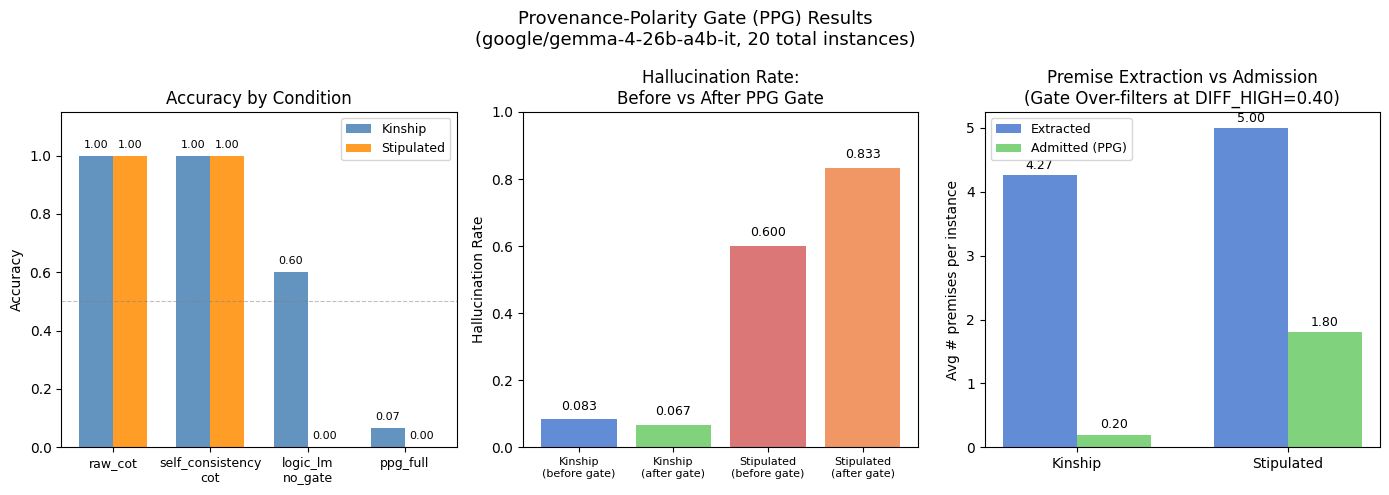

Saved ppg_results.png

=== Full-run Summary Table ===
Condition                  Kinship Acc  Stipulated Acc
-------------------------------------------------------
  raw_cot                        1.000           1.000
  self_consistency_cot           1.000           1.000
  logic_lm_no_gate               0.600           0.000
  ppg_full                       0.067           0.000

Hallucination reduction (kinship): 0.083 → 0.067
Avg admitted premises (kinship): 0.20 / 4.27 extracted

Phase 0 pre-flight: p=1.14e-06 (PASS)
Phase 1 pilot halluc rate: 0.075
Total API calls: 2089


In [11]:
# Use full-run metrics from loaded data for complete picture
km = data['metadata']['kinship_metrics']
sm = data['metadata']['stipulated_metrics']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Provenance-Polarity Gate (PPG) Results\n(google/gemma-4-26b-a4b-it, 20 total instances)', fontsize=13)

# --- Plot 1: Accuracy by condition ---
ax = axes[0]
conditions = ['raw_cot', 'self_consistency\ncot', 'logic_lm\nno_gate', 'ppg_full']
kinship_accs = [
    km['accuracy_raw_cot'],
    km['accuracy_self_consistency'],
    km['accuracy_logic_lm_no_gate'],
    km['accuracy_ppg'],
]
stip_accs = [
    sm['accuracy_raw_cot'],
    sm['accuracy_self_consistency'],
    sm['accuracy_logic_lm_no_gate'],
    sm['accuracy_ppg'],
]
x = np.arange(len(conditions))
w = 0.35
bars1 = ax.bar(x - w/2, kinship_accs, w, label='Kinship', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, stip_accs, w, label='Stipulated', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title('Accuracy by Condition')
ax.legend(fontsize=9)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# --- Plot 2: Hallucination rate before vs after PPG gate ---
ax = axes[1]
labels = ['Kinship\n(before gate)', 'Kinship\n(after gate)', 'Stipulated\n(before gate)', 'Stipulated\n(after gate)']
values = [
    km['gate_stats']['halluc_rate_before_gate'],
    km['gate_stats']['halluc_rate_after_gate'],
    sm['gate_stats']['halluc_rate_before_gate'],
    sm['gate_stats']['halluc_rate_after_gate'],
]
colors = ['#4878cf', '#6acc65', '#d65f5f', '#ee854a']
bars = ax.bar(labels, values, color=colors, alpha=0.85)
ax.set_ylabel('Hallucination Rate')
ax.set_ylim(0, 1.0)
ax.set_title('Hallucination Rate:\nBefore vs After PPG Gate')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', labelsize=8)

# --- Plot 3: Avg premises extracted vs admitted per dataset ---
ax = axes[2]
datasets = ['Kinship', 'Stipulated']
extracted = [km['avg_premises_extracted'], sm['avg_premises_extracted']]
admitted = [km['avg_premises_admitted'], sm['avg_premises_admitted']]
x = np.arange(len(datasets))
w = 0.35
b1 = ax.bar(x - w/2, extracted, w, label='Extracted', color='#4878cf', alpha=0.85)
b2 = ax.bar(x + w/2, admitted, w, label='Admitted (PPG)', color='#6acc65', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel('Avg # premises per instance')
ax.set_title('Premise Extraction vs Admission\n(Gate Over-filters at DIFF_HIGH=0.40)')
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('ppg_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved ppg_results.png")

# Summary table
print("\n=== Full-run Summary Table ===")
print(f"{'Condition':<25} {'Kinship Acc':>12} {'Stipulated Acc':>15}")
print("-" * 55)
rows = [
    ("raw_cot",             km['accuracy_raw_cot'],         sm['accuracy_raw_cot']),
    ("self_consistency_cot",km['accuracy_self_consistency'], sm['accuracy_self_consistency']),
    ("logic_lm_no_gate",    km['accuracy_logic_lm_no_gate'],sm['accuracy_logic_lm_no_gate']),
    ("ppg_full",            km['accuracy_ppg'],              sm['accuracy_ppg']),
]
for name, k_acc, s_acc in rows:
    print(f"  {name:<23} {k_acc:>12.3f} {s_acc:>15.3f}")

print(f"\nHallucination reduction (kinship): {km['gate_stats']['halluc_rate_before_gate']:.3f} → {km['gate_stats']['halluc_rate_after_gate']:.3f}")
print(f"Avg admitted premises (kinship): {km['avg_premises_admitted']:.2f} / {km['avg_premises_extracted']:.2f} extracted")
print(f"\nPhase 0 pre-flight: p={data['metadata']['phase0_preflight']['axis_separability']['p_value']:.2e} (PASS)")
print(f"Phase 1 pilot halluc rate: {data['metadata']['phase1_pilot']['baseline_halluc_rate']:.3f}")
print(f"Total API calls: {data['metadata']['api_cost_tracker']['calls']}")